# SUPPORT Semi-Synthetic Baseline Survival Prediction

Matched comparison of the original latent DVFM against a no-latent joint Weibull model on SUPPORT semi-synthetic Clayton-frailty data.

**Primary estimand:** oracle event-time recovery from covariates \(x\) only. Neither model receives test \(t\) or \(\delta\) at baseline prediction.


## Configuration

In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("outputs/support_clayton_frailty_tau05_baseline_latent_vs_no_latent")


In [2]:
latent_history = pd.DataFrame(
    [[1, 0.0013, 0.2978, 0.2974, 0.2505, 0.1876, 0.1872, 0.3888], [25, 0.0333, -1.8632, -2.0207, 4.7231, -1.9478, -2.1004, 0.7368], [50, 0.0667, -1.9952, -2.2453, 3.7521, -2.1409, -2.389, 0.7335], [75, 0.1, -1.9867, -2.3348, 3.4805, -2.1575, -2.5049, 0.7348], [100, 0.1333, -2.0351, -2.4887, 3.4021, -1.886, -2.3384, 0.7317], [125, 0.1667, -2.122, -2.6932, 3.4267, -2.1636, -2.7296, 0.7249], [150, 0.2, -2.1024, -2.7803, 3.3897, -2.1833, -2.863, 0.7188], [175, 0.2, -2.1753, -2.8557, 3.4016, -2.2117, -2.8926, 0.7166], [200, 0.2, -2.1265, -2.8141, 3.4381, -2.2781, -2.9654, 0.7179], [225, 0.2, -2.2426, -2.9371, 3.4727, -2.2677, -2.9628, 0.7192]],
    columns=["epoch","beta","train_loss","train_reconstruction_nll","train_kl",
             "validation_elbo","validation_nll","validation_abs_latent_r"]
)
no_latent_history = pd.DataFrame(
    [[1, 0.3206, 0.2947], [25, -0.5356, -0.3326], [50, -0.587, -0.3347], [75, -0.6039, -0.32], [100, -0.5973, -0.3213], [125, -0.5958, -0.3184], [150, -0.592, -0.31]],
    columns=["epoch","train_nll","validation_nll"]
)

if (OUTPUT_DIR / "latent_training_history.csv").exists():
    latent_history = pd.read_csv(OUTPUT_DIR / "latent_training_history.csv")
if (OUTPUT_DIR / "no_latent_training_history.csv").exists():
    no_latent_history = pd.read_csv(OUTPUT_DIR / "no_latent_training_history.csv")

latent_history


,epoch,beta,train_loss,train_reconstruction_nll,train_kl,validation_elbo,validation_nll,validation_abs_latent_r
0,1,0.0013,0.2978,0.2974,0.2505,0.1876,0.1872,0.3888
1,25,0.0333,-1.8632,-2.0207,4.7231,-1.9478,-2.1004,0.7368
2,50,0.0667,-1.9952,-2.2453,3.7521,-2.1409,-2.3890,0.7335
3,75,0.1000,-1.9867,-2.3348,3.4805,-2.1575,-2.5049,0.7348
4,100,0.1333,-2.0351,-2.4887,3.4021,-1.8860,-2.3384,0.7317
5,125,0.1667,-2.1220,-2.6932,3.4267,-2.1636,-2.7296,0.7249
6,150,0.2000,-2.1024,-2.7803,3.3897,-2.1833,-2.8630,0.7188
7,175,0.2000,-2.1753,-2.8557,3.4016,-2.2117,-2.8926,0.7166
8,200,0.2000,-2.1265,-2.8141,3.4381,-2.2781,-2.9654,0.7179
9,225,0.2000,-2.2426,-2.9371,3.4727,-2.2677,-2.9628,0.7192


## Final baseline comparison

In [3]:
summary = pd.DataFrame({
    "Model": ["Latent DVFM", "No latent"],
    "Oracle CI": [0.5958, 0.6077],
    "Oracle IBS": [0.1434, 0.1402],
    "Oracle MAE": [np.inf, 3345.5364],
})
summary


,Model,Oracle CI,Oracle IBS,Oracle MAE
0,Latent DVFM,0.5958,0.1434,inf
1,No latent,0.6077,0.1402,3345.5364


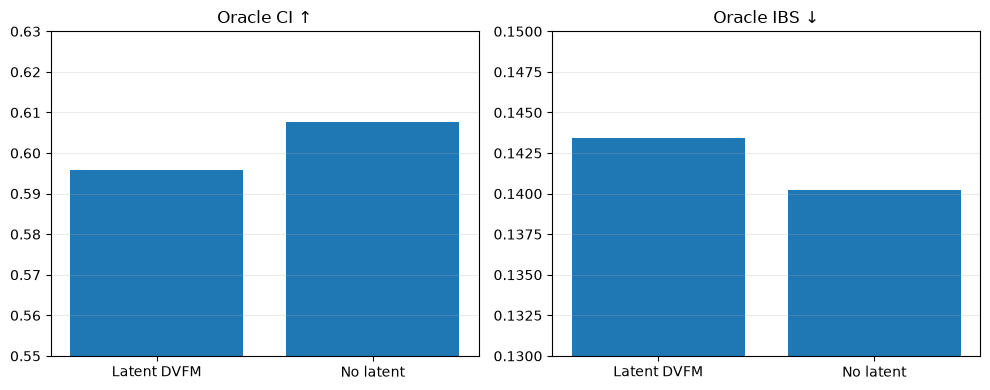

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(summary["Model"], summary["Oracle CI"])
axes[0].set_title("Oracle CI ↑")
axes[0].set_ylim(0.55, 0.63)
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(summary["Model"], summary["Oracle IBS"])
axes[1].set_title("Oracle IBS ↓")
axes[1].set_ylim(0.13, 0.15)
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


### Result

- Delta Oracle CI: **−0.0120**
- Delta Oracle IBS: **+0.0032**
- Latent Oracle MAE: **infinite** due to numerical overflow in the Weibull mean

The aggregate-posterior latent model does not outperform the no-latent model in this run.


## DVFM training

,epoch,beta,train_loss,train_reconstruction_nll,train_kl,validation_elbo,validation_nll,validation_abs_latent_r
0,1,0.0013,0.2978,0.2974,0.2505,0.1876,0.1872,0.3888
1,25,0.0333,-1.8632,-2.0207,4.7231,-1.9478,-2.1004,0.7368
2,50,0.0667,-1.9952,-2.2453,3.7521,-2.1409,-2.3890,0.7335
3,75,0.1000,-1.9867,-2.3348,3.4805,-2.1575,-2.5049,0.7348
4,100,0.1333,-2.0351,-2.4887,3.4021,-1.8860,-2.3384,0.7317
5,125,0.1667,-2.1220,-2.6932,3.4267,-2.1636,-2.7296,0.7249
6,150,0.2000,-2.1024,-2.7803,3.3897,-2.1833,-2.8630,0.7188
7,175,0.2000,-2.1753,-2.8557,3.4016,-2.2117,-2.8926,0.7166
8,200,0.2000,-2.1265,-2.8141,3.4381,-2.2781,-2.9654,0.7179
9,225,0.2000,-2.2426,-2.9371,3.4727,-2.2677,-2.9628,0.7192


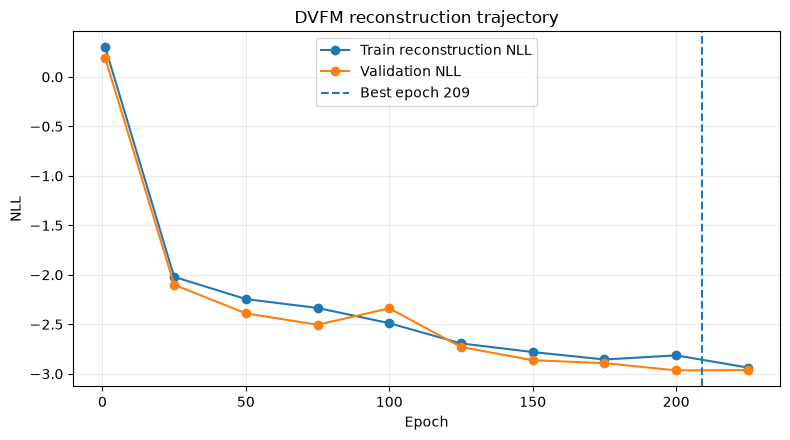

In [5]:
display(latent_history)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(latent_history["epoch"], latent_history["train_reconstruction_nll"], marker="o", label="Train reconstruction NLL")
ax.plot(latent_history["epoch"], latent_history["validation_nll"], marker="o", label="Validation NLL")
ax.axvline(209, linestyle="--", label="Best epoch 209")
ax.set_xlabel("Epoch")
ax.set_ylabel("NLL")
ax.set_title("DVFM reconstruction trajectory")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


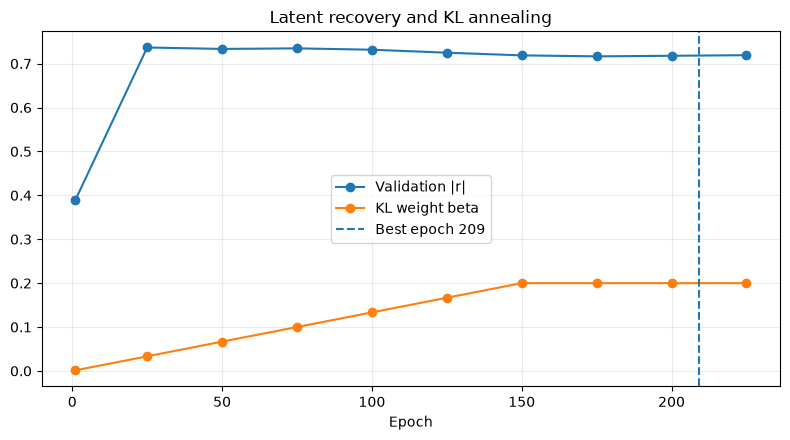

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(latent_history["epoch"], latent_history["validation_abs_latent_r"], marker="o", label="Validation |r|")
ax.plot(latent_history["epoch"], latent_history["beta"], marker="o", label="KL weight beta")
ax.axvline(209, linestyle="--", label="Best epoch 209")
ax.set_xlabel("Epoch")
ax.set_title("Latent recovery and KL annealing")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


Latent recovery reaches roughly \(0.73\) by epoch 25 and then remains stable. Reconstruction continues improving much later. This indicates that checkpoint selection by posterior-conditioned validation NLL is not directly aligned with baseline marginalized prediction.


## No-latent training

,epoch,train_nll,validation_nll
0,1,0.3206,0.2947
1,25,-0.5356,-0.3326
2,50,-0.5870,-0.3347
3,75,-0.6039,-0.3200
4,100,-0.5973,-0.3213
5,125,-0.5958,-0.3184
6,150,-0.5920,-0.3100


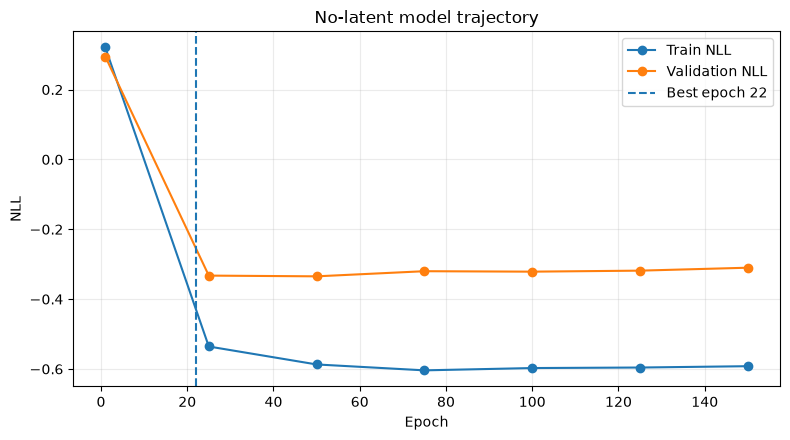

In [7]:
display(no_latent_history)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(no_latent_history["epoch"], no_latent_history["train_nll"], marker="o", label="Train NLL")
ax.plot(no_latent_history["epoch"], no_latent_history["validation_nll"], marker="o", label="Validation NLL")
ax.axvline(22, linestyle="--", label="Best epoch 22")
ax.set_xlabel("Epoch")
ax.set_ylabel("NLL")
ax.set_title("No-latent model trajectory")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Interpretation

This run supports successful recovery of dependence-relevant latent structure, but not improved prospective baseline prediction after marginalizing the latent.

The clean conclusion is:

> The original DVFM learns a useful posterior latent representation, but aggregate-posterior marginalization does not improve the event-time distribution relative to the matched no-latent model in this setting.

The infinite MAE should be treated as a numerical failure of Weibull-mean computation, not as a meaningful scientific estimate. Oracle CI and IBS are the reliable comparison metrics here.
